In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
loan_data=pd.read_csv("loan_approval_data.csv")
loan_data.head()
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [3]:
loan_data.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [4]:
categorical_cols=loan_data.select_dtypes(include=["object"]).columns
numerical_cols=loan_data.select_dtypes(include=["number"]).columns

In [5]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [6]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [7]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="mean")

loan_data[numerical_cols]=num_imp.fit_transform(loan_data[numerical_cols])

In [8]:
loan_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [9]:
cat_imp=SimpleImputer(strategy="most_frequent")
loan_data[categorical_cols]=cat_imp.fit_transform(loan_data[categorical_cols])

In [10]:
loan_data.head()
loan_data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [12]:
le=LabelEncoder()

loan_data["Education_Level"]=le.fit_transform(loan_data["Education_Level"])
loan_data["Gender"]=le.fit_transform(loan_data["Gender"])    
loan_data["Loan_Approved"]=le.fit_transform(loan_data["Loan_Approved"])




In [13]:
loan_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,0,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,1,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,0,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,0,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,1,Private,1


In [14]:
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Employer_Category"]

encoded=ohe.fit_transform(loan_data[cols])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=loan_data.index)

In [15]:
loan_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,0,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,1,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,0,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,0,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,1,Private,1


In [16]:
loan_data=pd.concat([loan_data.drop(columns=cols),encoded_df],axis=1)

In [17]:
num_cols=loan_data.select_dtypes(include="number")
corr_matrix=num_cols.corr()

In [18]:
corr_matrix

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_ID,1.000000,0.020970,0.041140,0.014579,0.012495,-0.028170,0.024995,0.000174,0.022692,0.031759,...,0.017845,0.005426,-0.039878,0.019178,0.012969,-0.030187,0.005906,-0.074056,0.022803,0.038417
Applicant_Income,0.020970,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,...,-0.083398,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.041140,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,...,-0.020148,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.001146,0.037640,0.004312,-0.047929
Age,0.014579,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,...,-0.025521,-0.006283,0.029865,0.037293,0.003100,-0.025661,-0.066041,0.021232,-0.012960,0.072462
Dependents,0.012495,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,...,-0.043685,-0.044642,0.027343,-0.005785,-0.032278,0.024082,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.028170,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,...,-0.030142,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,0.024995,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,...,-0.025228,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,0.000174,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,...,-0.020907,0.040432,-0.014125,-0.036648,0.044898,-0.006156,-0.007214,0.002090,-0.003506,0.026018
Savings,0.022692,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,...,-0.009133,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.031759,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,...,0.031112,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.035760,-0.013464,-0.014480,-0.009655


<Axes: >

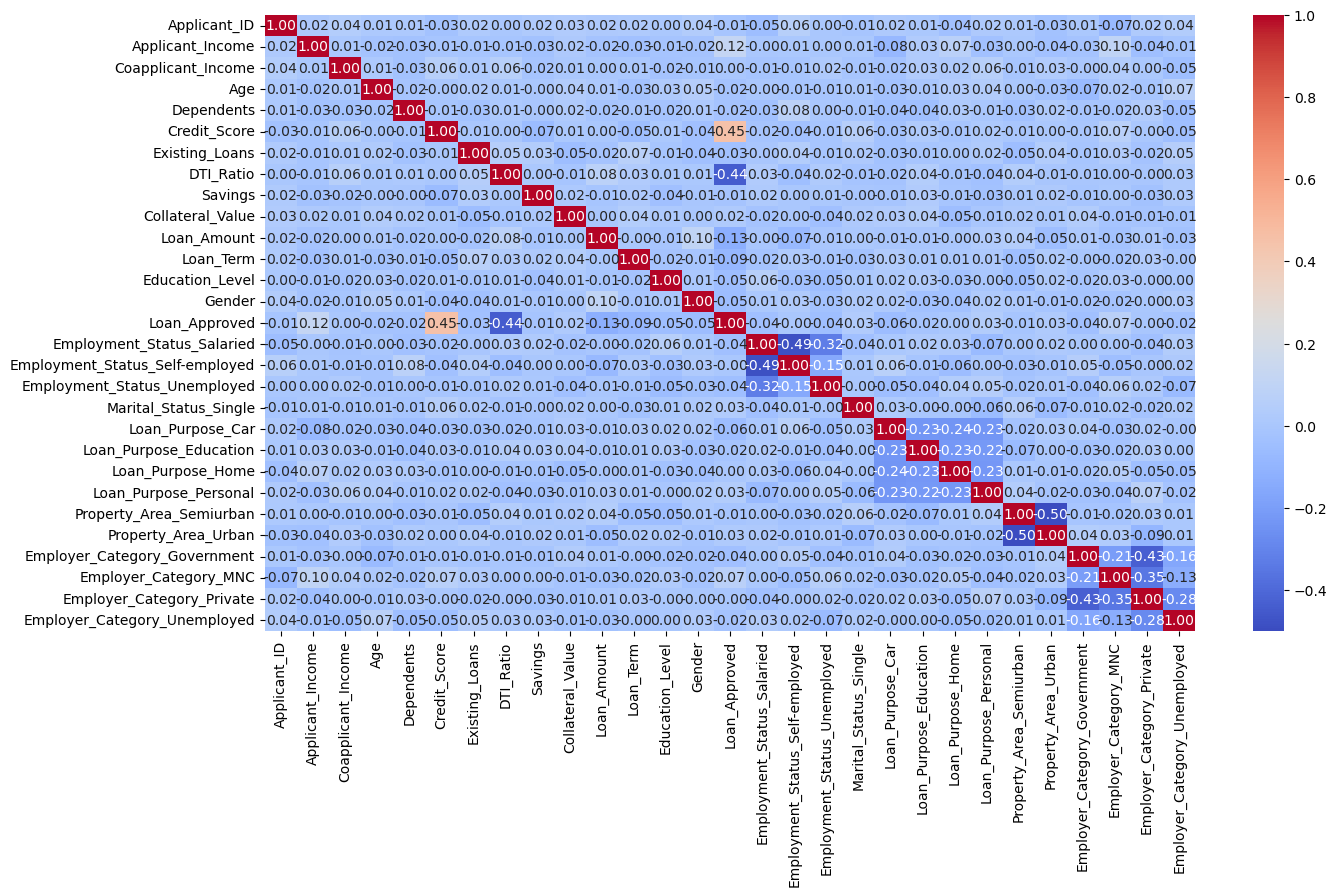

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [20]:
X=loan_data.drop("Loan_Approved",axis=1)
y=loan_data["Loan_Approved"]

In [21]:
X.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [22]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=56)

In [24]:
X_train.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
752,753.00,4048.0,9667.0,28.0,0.0,677.0,2.0,0.46,7238.0,21424.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
359,360.00,15245.0,3342.0,46.0,3.0,641.0,1.0,0.54,17772.0,16498.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
493,494.00,3214.0,3638.0,41.0,1.0,779.0,3.0,0.13,1883.0,13782.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
419,501.22,9357.0,583.0,41.0,3.0,567.0,1.0,0.14,18344.0,3196.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
924,925.00,19072.0,7045.0,51.0,3.0,633.0,4.0,0.12,7953.0,31912.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [25]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [26]:
X_train.dtypes

Applicant_ID                       float64
Applicant_Income                   float64
Coapplicant_Income                 float64
Age                                float64
Dependents                         float64
Credit_Score                       float64
Existing_Loans                     float64
DTI_Ratio                          float64
Savings                            float64
Collateral_Value                   float64
Loan_Amount                        float64
Loan_Term                          float64
Education_Level                      int64
Gender                               int64
Employment_Status_Salaried         float64
Employment_Status_Self-employed    float64
Employment_Status_Unemployed       float64
Marital_Status_Single              float64
Loan_Purpose_Car                   float64
Loan_Purpose_Education             float64
Loan_Purpose_Home                  float64
Loan_Purpose_Personal              float64
Property_Area_Semiurban            float64
Property_Ar

In [27]:
loan_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.6904761904761905
Recall: 0.6041666666666666
F1 score: 0.6444444444444445
Accuracy: 0.84
CM: [[139  13]
 [ 19  29]]


In [29]:
loan_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [30]:
loan_data.dtypes

Applicant_ID                       float64
Applicant_Income                   float64
Coapplicant_Income                 float64
Age                                float64
Dependents                         float64
Credit_Score                       float64
Existing_Loans                     float64
DTI_Ratio                          float64
Savings                            float64
Collateral_Value                   float64
Loan_Amount                        float64
Loan_Term                          float64
Education_Level                      int64
Gender                               int64
Loan_Approved                        int64
Employment_Status_Salaried         float64
Employment_Status_Self-employed    float64
Employment_Status_Unemployed       float64
Marital_Status_Single              float64
Loan_Purpose_Car                   float64
Loan_Purpose_Education             float64
Loan_Purpose_Home                  float64
Loan_Purpose_Personal              float64
Property_Ar

In [31]:
encoded=ohe.fit_transform(loan_data[["Gender"]])

gender_df=pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["Gender"]),
    index=loan_data.index
)

loan_data=loan_data.drop(columns=["Gender"])
loan_data=pd.concat([loan_data,gender_df],axis=1)

In [32]:
from sklearn.neighbors import KNeighborsClassifier

neighbor_model=KNeighborsClassifier(n_neighbors=5)
neighbor_model.fit(X_train_scaled,y_train)

y_pred=neighbor_model.predict(X_test_scaled)

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))



Precision: 0.6190476190476191
Recall: 0.5416666666666666
F1 score: 0.5777777777777777
Accuracy: 0.81
CM: [[136  16]
 [ 22  26]]


In [33]:
from sklearn.naive_bayes import GaussianNB

nb_model=GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred=nb_model.predict(X_test_scaled)

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.8157894736842105
Recall: 0.6458333333333334
F1 score: 0.7209302325581395
Accuracy: 0.88
CM: [[145   7]
 [ 17  31]]


In [41]:
loan_data["DTI_Ratio_sq"]=loan_data["DTI_Ratio"] ** 2
loan_data["Credit_Score_sq"]=loan_data["Credit_Score"] ** 2

loan_data["Applicant_Income_log"]=np.log1p(loan_data["Applicant_Income"])


X=loan_data.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio","Applicant_Income"])
y=loan_data["Loan_Approved"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=56
)

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
                 



In [37]:
X_train.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,...,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_1,DIT_Ratio_sq,Credit_Score_sq,Applicant_Income_log,DTI_Ratio_sq
752,753.00,4048.0,9667.0,28.0,0.0,2.0,7238.0,21424.0,1824.000000,24.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.2116,458329.0,8.306225,0.2116
359,360.00,15245.0,3342.0,46.0,3.0,1.0,17772.0,16498.0,20522.825263,48.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.2916,410881.0,9.632072,0.2916
493,494.00,3214.0,3638.0,41.0,1.0,3.0,1883.0,13782.0,6950.000000,60.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0169,606841.0,8.075583,0.0169
419,501.22,9357.0,583.0,41.0,3.0,1.0,18344.0,3196.0,8803.000000,60.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0196,321489.0,9.143987,0.0196
924,925.00,19072.0,7045.0,51.0,3.0,4.0,7953.0,31912.0,38317.000000,24.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0144,400689.0,9.856029,0.0144


In [42]:
#Naive

from sklearn.naive_bayes import GaussianNB

nb_model=GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred=nb_model.predict(X_test_scaled)

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))


Precision: 0.6666666666666666
Recall: 0.75
F1 score: 0.7058823529411765
Accuracy: 0.85
CM: [[134  18]
 [ 12  36]]


In [43]:
#KNN

from sklearn.neighbors import KNeighborsClassifier

neighbor_model=KNeighborsClassifier(n_neighbors=5)
neighbor_model.fit(X_train_scaled,y_train)

y_pred=neighbor_model.predict(X_test_scaled)

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))



Precision: 0.6444444444444445
Recall: 0.6041666666666666
F1 score: 0.6236559139784946
Accuracy: 0.825
CM: [[136  16]
 [ 19  29]]


In [44]:
#Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.7111111111111111
Recall: 0.6666666666666666
F1 score: 0.6881720430107527
Accuracy: 0.855
CM: [[139  13]
 [ 16  32]]
